In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import os, subprocess
import cooler
import cooltools.lib.plotting
import cooltools
import warnings
import bioframe
warnings.filterwarnings("ignore")
from cytoolz import merge

In [2]:
def saddleplot(
    track,
    saddledata,
    n_bins,
    vrange=None,
    qrange=(0.0, 1.0),
    cmap="coolwarm",
    scale="log",
    vmin=0.5,
    vmax=2.5,
    color=None,
    title=None,
    xlabel=None,
    ylabel=None,
    clabel=None,
    fig=None,
    fig_kws=None,
    heatmap_kws=None,
    margin_kws=None,
    cbar_kws=None,
    subplot_spec=None,
):
    """
    Generate a saddle plot.
    Parameters
    ----------
    track : pd.DataFrame
        See cooltools.digitize() for details.
    saddledata : 2D array-like
        Saddle matrix produced by `make_saddle`. It will include 2 flanking
        rows/columns for outlier signal values, thus the shape should be
        `(n+2, n+2)`.
    cmap : str or matplotlib colormap
        Colormap to use for plotting the saddle heatmap
    scale : str
        Color scaling to use for plotting the saddle heatmap: log or linear
    vmin, vmax : float
        Value limits for coloring the saddle heatmap
    color : matplotlib color value
        Face color for margin bar plots
    fig : matplotlib Figure, optional
        Specified figure to plot on. A new figure is created if none is
        provided.
    fig_kws : dict, optional
        Passed on to `plt.Figure()`
    heatmap_kws : dict, optional
        Passed on to `ax.imshow()`
    margin_kws : dict, optional
        Passed on to `ax.bar()` and `ax.barh()`
    cbar_kws : dict, optional
        Passed on to `plt.colorbar()`
    subplot_spec : GridSpec object
        Specify a subregion of a figure to using a GridSpec.
    Returns
    -------
    Dictionary of axes objects.
    """

    from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
    from matplotlib.colors import Normalize, LogNorm
    from matplotlib import ticker
    import matplotlib.pyplot as plt

    class MinOneMaxFormatter(ticker.LogFormatter):
        def set_locs(self, locs=None):
            self._sublabels = set([vmin % 10 * 10, vmax % 10, 1])

        def __call__(self, x, pos=None):
            if x not in [vmin, 1, vmax]:
                return ""
            else:
                return "{x:g}".format(x=x)

    track_value_col = track.columns[3]
    track_values = track[track_value_col].values

    digitized_track, binedges = cooltools.digitize(
        track, n_bins, vrange=vrange, qrange=qrange
    )
    x = digitized_track[digitized_track.columns[3]].values.astype(int).copy()
    x = x[(x > -1) & (x < len(binedges) + 1)]
    
    # Old version
    # hist = np.bincount(x, minlength=len(binedges) + 1)

    groupmean = track[track.columns[3]].groupby(digitized_track[digitized_track.columns[3]]).mean()
    
    if qrange is not None:
        lo, hi = qrange
        binedges = np.linspace(lo, hi, n_bins + 1)
    
    # Barplot of mean values and saddledata are flanked by outlier bins
    n = saddledata.shape[0]
    X, Y = np.meshgrid(binedges, binedges)
    C = saddledata
    if (n - n_bins) == 2:
        C = C[1:-1, 1:-1]
        groupmean = groupmean[1:-1]

    # Layout
    if subplot_spec is not None:
        GridSpec = partial(GridSpecFromSubplotSpec, subplot_spec=subplot_spec)
    grid = {}
    gs = GridSpec(
        nrows=3,
        ncols=3,
        width_ratios=[0.2, 1, 0.1],
        height_ratios=[0.2, 1, 0.1],
        wspace=0.05,
        hspace=0.05,
    )

    # Figure
    if fig is None:
        fig_kws_default = dict(figsize=(5, 5))
        fig_kws = merge(fig_kws_default, fig_kws if fig_kws is not None else {})
        fig = plt.figure(**fig_kws)

    # Heatmap
    if scale == "log":
        norm = LogNorm(vmin=vmin, vmax=vmax)
    elif scale == "linear":
        norm = Normalize(vmin=vmin, vmax=vmax)
    else:
        raise ValueError("Only linear and log color scaling is supported")

    grid["ax_heatmap"] = ax = plt.subplot(gs[4])
    heatmap_kws_default = dict(cmap="coolwarm", rasterized=True)
    heatmap_kws = merge(
        heatmap_kws_default, heatmap_kws if heatmap_kws is not None else {}
    )
    img = ax.pcolormesh(X, Y, C, norm=norm, **heatmap_kws)
    plt.gca().yaxis.set_visible(False)

    # Margins
    margin_kws_default = dict(edgecolor="k", facecolor=color, linewidth=1)
    margin_kws = merge(margin_kws_default, margin_kws if margin_kws is not None else {})
    # left margin hist
    grid["ax_margin_y"] = plt.subplot(gs[3], sharey=grid["ax_heatmap"])
    
    plt.barh(
        binedges, height=1/len(binedges), width=groupmean, align="edge", **margin_kws
    )
    
    plt.xlim(plt.xlim()[1], plt.xlim()[0])  # fliplr
    plt.ylim(hi, lo)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["bottom"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().xaxis.set_visible(False)
    # top margin hist
    grid["ax_margin_x"] = plt.subplot(gs[1], sharex=grid["ax_heatmap"])
    
    plt.bar(
        binedges, width=1/len(binedges), height=groupmean, align="edge", **margin_kws
    )
    
    plt.xlim(lo, hi)
    # plt.ylim(plt.ylim())  # correct
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().xaxis.set_visible(False)
    plt.gca().yaxis.set_visible(False)

#     # Colorbar
    grid["ax_cbar"] = plt.subplot(gs[5])
    cbar_kws_default = dict(fraction=0.8, label=clabel or "")
    cbar_kws = merge(cbar_kws_default, cbar_kws if cbar_kws is not None else {})
    if scale == "linear" and vmin is not None and vmax is not None:
        grid["ax_cbar"] = cb = plt.colorbar(img, **cbar_kws)
        # cb.set_ticks(np.arange(vmin, vmax + 0.001, 0.5))
        # # do linspace between vmin and vmax of 5 segments and trunc to 1 decimal:
        decimal = 10
        nsegments = 5
        cd_ticks = np.trunc(np.linspace(vmin, vmax, nsegments) * decimal) / decimal
        cb.set_ticks(cd_ticks)
    else:
        print('cbar')
        
        cb = plt.colorbar(img, format=MinOneMaxFormatter(), cax=grid["ax_cbar"], **cbar_kws)
        cb.ax.yaxis.set_minor_formatter(MinOneMaxFormatter())

    # extra settings
    grid["ax_heatmap"].set_xlim(lo, hi)
    grid["ax_heatmap"].set_ylim(hi, lo)
    grid['ax_heatmap'].grid(False)
    if title is not None:
        grid["ax_margin_x"].set_title(title)
    if xlabel is not None:
        grid["ax_heatmap"].set_xlabel(xlabel)
    if ylabel is not None:
        grid["ax_margin_y"].set_ylabel(ylabel)
    # plt.savefig('/mnt/data/kaustav/Hi-c/data_from_sriram_24_7_24/hic_files_with_dups_MAPQ_30/2024-02-and-04-Rep-HiC-UT-MRC5-G9ai-merged_merged_sort_MAPQ_30_50000.svg', dpi=1200, format='svg')
    return grid

In [3]:
if not os.path.isfile('./hg38.fa'):
    ## note downloading a ~1Gb file can take a minute
    subprocess.call('wget --progress=bar:force:noscroll https://hgdownload.cse.ucsc.edu/goldenpath/hg38/bigZips/hg38.fa.gz', shell=True)
    subprocess.call('gunzip hg38.fa.gz', shell=True)

--2025-08-28 10:13:45--  https://hgdownload.cse.ucsc.edu/goldenpath/hg38/bigZips/hg38.fa.gz
Resolving hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)|128.114.119.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 983659424 (938M) [application/x-gzip]
Saving to: ‘hg38.fa.gz’

hg38.fa.gz          100%[===================>] 938.09M  4.99MB/s    in 2m 47s  

2025-08-28 10:16:34 (5.63 MB/s) - ‘hg38.fa.gz’ saved [983659424/983659424]

gunzip: hg38.fa.gz has 1 other links -- skipping


In [107]:
ut_file = '/mnt'
ut_cool = '/mnt/data/kaustav/Hi-c/data_from_sriram_24_7_24/hic_files_with_dups_MAPQ_30/2021-09-10-Rep-HiC-HU.merged_sort.MAPQ.30.cool'
# hu_file = '/mnt/data/kaustav/Hi-c/data_from_sriram_24_7_24/hic_cool_files_HCT116_WT/2024-08-13-HiC-HU-HCT116.merged_sort.MAPQ.30.hic'
# hu_cool = '/mnt/data/kaustav/Hi-c/data_from_sriram_24_7_24/hic_cool_files_HCT116_WT/2024-08-13-HiC-HU-HCT116_merged_sort_MAPQ_30.cool'
res = 50000

In [4]:
Q_LO = 0.025 # ignore 2.5% of genomic bins with the lowest E1 values
Q_HI = 0.975 # ignore 2.5% of genomic bins with the highest E1 values
N_GROUPS = 50 # divide remaining 95% of the genome into 38 equisized groups, 2.5% each

In [109]:
os.system(f"hicConvertFormat -m {ut_file} --inputFormat hic --outputFormat cool -o {ut_cool} --resolution {res}")
print(f"{ut_cool.split('.')[0]}_{str(res)}.cool")

INFO:hicexplorer.hicConvertFormat:Converting with hic2cool.


##########################
### hic2cool / convert ###
##########################
### Header info from hic
... Chromosomes:  ['All', 'chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrM', 'chrX', 'chrY']
... Resolutions:  [50000, 25000, 10000]
... Normalizations:  ['VC', 'VC_SQRT', 'KR', 'SCALE']
... Genome:  /home/srirvs/references/hg38.chrom.sizes
### Converting
... Resolution 50000 took: 82.47194194793701 seconds.
### Finished! Output written to: /mnt/data/kaustav/Hi-c/data_from_sriram_24_7_24/hic_files_with_dups_MAPQ_30/2021-09-10-Rep-HiC-HU.merged_sort.MAPQ.30_50000.cool
... This file is single resolution and NOT higlass compatible. Run with `-r 0` for multi-resolution.
/mnt/data/kaustav/Hi-c/data_from_sriram_24_7_24/hic_files_with_dups_MAPQ_30/2021-09-10-Rep-HiC-HU_50000.cool


In [110]:
os.system(f"hicConvertFormat -m /mnt/data/kaustav/Hi-c/data_from_sriram_24_7_24/hic_files_with_dups_MAPQ_30/2021-09-10-Rep-HiC-HU.merged_sort.MAPQ.30_50000.cool --inputFormat cool --outputFormat cool -o /mnt/data/kaustav/Hi-c/data_from_sriram_24_7_24/hic_files_with_dups_MAPQ_30/2021-09-10-Rep-HiC-HU.merged_sort.MAPQ.30_50000_wt.cool --correction_name KR")

0

In [126]:
# clr = cooler.Cooler('./hic/2021-09-10-Rep-HiC-HU_50000.dups.cool')

# with clr.open('r+') as f:
#     f["bins"].create_dataset("KR_mult", data=1./f["bins/KR"][:], 
# compression="gzip", compression_opts=6)

# if not os.path.isfile(f'{ut_cool.split(".")[0]}_wt_{str(res)}.cool'):
    # os.system(f"hicConvertFormat -m {ut_file} --inputFormat hic --outputFormat cool -o {ut_cool} --resolution {res}")
#     print(f"{ut_cool.split('.')[0]}_{str(res)}.cool")
#     os.system(f"hicConvertFormat -m {ut_cool.split('.')[0]}_{str(res)}.cool --inputFormat cool --outputFormat cool -o {ut_cool.split('.')[0]}_wt_{str(res)}.cool --correction_name KR")

rename_dict = {'1':'chr1', '10':'chr10', '11':'chr11', '12':'chr12', '13':'chr13', '14':'chr14', '15':'chr15', 
               '16':'chr16', '17':'chr17', '18':'chr18', '19':'chr19', '2':'chr2', '20':'chr20', '21':'chr21', '22':'chr22',
               '3':'chr3', '4':'chr4', '5':'chr5', '6':'chr6', '7':'chr7', '8':'chr8', '9':'chr9', 
               'M':'chrM', 'X':'chrX', 'Y':'chrY'}

# clr = cooler.Cooler(f'{ut_cool.split(".")[0]}_wt_{str(res)}.cool')
# os.system(f"hicConvertFormat -m /mnt/data/kaustav/Hi-c/data_from_sriram_24_7_24/hic_files_with_dups_MAPQ_30/2023-11-04-Rep-HiC-NT_rerun_merged_sort_MAPQ_30_50000.cool --inputFormat cool --outputFormat cool -o /mnt/data/kaustav/Hi-c/data_from_sriram_24_7_24/hic_files_with_dups_MAPQ_30/2023-11-04-Rep-HiC-NT_rerun_merged_sort_MAPQ_30_50000_wt.cool --correction_name KR")
clr = cooler.Cooler('/mnt/data/kaustav/Hi-c/data_from_sriram_24_7_24/HiC_expt_cool_files_50kb/2023-11-04-HiC-NT.merged_sort.MAPQ.30.50k.cool')
# with clr.open('r+') as f:
#     f["bins"].create_dataset("weight", data=1./f["bins/KR"][:], 
# compression="gzip", compression_opts=6)

In [127]:
print(clr.chromnames,clr.binsize)

['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrM', 'chrX', 'chrY'] 50000


In [128]:
cooler.rename_chroms(clr, rename_dict, h5opts=None)

In [129]:
print(clr.chromnames,clr.binsize)

['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrM', 'chrX', 'chrY'] 50000


In [130]:
import bioframe
bins = clr.bins()[:]
hg38_genome = bioframe.load_fasta('./hg38.fa');
## note the next command may require installing pysam
gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)
# gc_cov.to_csv('hg38_gc_cov_100kb.tsv',index=False,sep='\t')
# display(gc_cov)

In [131]:
view_df = pd.DataFrame({'chrom': clr.chromnames,
                        'start': 0,
                        'end': clr.chromsizes.values,
                        'name': clr.chromnames}
                      )
# display(view_df)

In [132]:
cis_eigs = cooltools.eigs_cis(
                        clr,
                        gc_cov,
                        view_df=view_df,
                        n_eigs=3,
                        # clr_weight_name='KR_mult'
                        )

# cis_eigs[0] returns eigenvalues, here we focus on eigenvectors
eigenvector_track = cis_eigs[1][['chrom','start','end','E1']]
eigenvector_track_ut = cis_eigs[1][['chrom','start','end','E1']]

In [133]:
# eigenvector_track = pd.read_csv('./compartment_analysis/all_2023-11-04-HiC-HU_50000.AorB.xls' Change here for custom EV track
#                                 , sep='\t', header=None)
# eigenvector_track = eigenvector_track.drop([3, 5], axis=1)
# eigenvector_track.columns = ['chrom',	'start', 'end', 'E1']
# # eigenvector_track = eigenvector_track[eigenvector_track['chrom'] == 'chr1']
# eigenvector_track = cis_eigs[1]
# eigenvector_track

In [134]:
cvd = cooltools.expected_cis(
        clr=clr,
        view_df=view_df,
        nproc=10,
        # clr_weight_name='KR_mult'
        )

INFO:root:creating a Pool of 10 workers


In [135]:
interaction_sum, interaction_count =  cooltools.saddle(
        clr,
        cvd,
        eigenvector_track,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df,
        # clr_weight_name='KR_mult',
        verbose=True)

regions chr1 vs chr1
regions chr10 vs chr10
regions chr11 vs chr11
regions chr12 vs chr12
regions chr13 vs chr13
regions chr14 vs chr14
regions chr15 vs chr15
regions chr16 vs chr16
regions chr17 vs chr17
regions chr18 vs chr18
regions chr19 vs chr19
regions chr2 vs chr2
regions chr20 vs chr20
regions chr21 vs chr21
regions chr22 vs chr22
regions chr3 vs chr3
regions chr4 vs chr4
regions chr5 vs chr5
regions chr6 vs chr6
regions chr7 vs chr7
regions chr8 vs chr8
regions chr9 vs chr9
regions chrM vs chrM
regions chrX vs chrX
regions chrY vs chrY


cbar


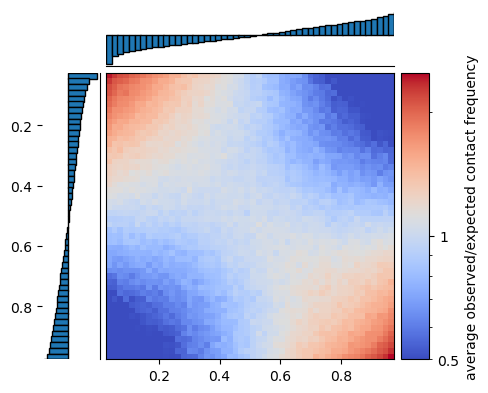

In [136]:
saddleplot(eigenvector_track,
           interaction_sum/interaction_count,
           N_GROUPS,
           qrange=(Q_LO,Q_HI),
           cbar_kws={'label':'average observed/expected contact frequency'},
          );

In [137]:
nt_values = interaction_sum/interaction_count
nt_values = np.nan_to_num(nt_values, nan=0)

HU Part of the code.

In [138]:
# clr = cooler.Cooler('./hic/2021-09-10-Rep-HiC-HU_50000.dups.cool')

# with clr.open('r+') as f:
#     f["bins"].create_dataset("KR_mult", data=1./f["bins/KR"][:], 
# compression="gzip", compression_opts=6)

# if not os.path.isfile(f'{hu_cool.split(".")[0]}_wt_{str(res)}.cool'):
#     os.system(f"hicConvertFormat -m {hu_file} --inputFormat hic --outputFormat cool -o {hu_cool} --resolution {res}")
#     print(f"{hu_cool.split('.')[0]}_{str(res)}.cool")
#     os.system(f"hicConvertFormat -m {hu_cool.split('.')[0]}_{str(res)}.cool --inputFormat cool --outputFormat cool -o {hu_cool.split('.')[0]}_wt_{str(res)}.cool --correction_name KR")

rename_dict = {'1':'chr1', '10':'chr10', '11':'chr11', '12':'chr12', '13':'chr13', '14':'chr14', '15':'chr15', 
               '16':'chr16', '17':'chr17', '18':'chr18', '19':'chr19', '2':'chr2', '20':'chr20', '21':'chr21', '22':'chr22',
               '3':'chr3', '4':'chr4', '5':'chr5', '6':'chr6', '7':'chr7', '8':'chr8', '9':'chr9', 
               'M':'chrM', 'X':'chrX', 'Y':'chrY'}

# clr = cooler.Cooler(f"{hu_cool.split('.')[0]}_wt_{str(res)}.cool")
clr = cooler.Cooler('/mnt/data/kaustav/Hi-c/data_from_sriram_24_7_24/HiC_expt_cool_files_50kb/2023-11-04-HiC-HU.merged_sort.MAPQ.30.50k.cool')
# # # matrix_hu = clr.matrix(sparse=True, balance=True)
# # # matrix_hu
# with clr.open('r+') as f:
#     f["bins"].create_dataset("weight", data=1./f["bins/KR"][:], 
# compression="gzip", compression_opts=6)

In [139]:
print(clr.chromnames,clr.binsize)

['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrM', 'chrX', 'chrY'] 50000


In [140]:
cooler.rename_chroms(clr, rename_dict, h5opts=None)

In [141]:
print(clr.chromnames,clr.binsize)

['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrM', 'chrX', 'chrY'] 50000


In [142]:
view_df = pd.DataFrame({'chrom': clr.chromnames,
                        'start': 0,
                        'end': clr.chromsizes.values,
                        'name': clr.chromnames}
                      )
# display(view_df)

In [143]:
bins = clr.bins()[:]
# hg38_genome = bioframe.load_fasta('./hg38.fa');
## note the next command may require installing pysam
gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)
# gc_cov.to_csv('hg38_gc_cov_100kb.tsv',index=False,sep='\t')
# display(gc_cov)

In [144]:
cis_eigs = cooltools.eigs_cis(
                        clr,
                        gc_cov,
                        view_df=view_df,
                        n_eigs=3,
                        # clr_weight_name='KR_mult'
                        )

# cis_eigs[0] returns eigenvalues, here we focus on eigenvectors
eigenvector_track = cis_eigs[1][['chrom','start','end','E1']]
eigenvector_track_hu = cis_eigs[1][['chrom','start','end','E1']]

In [145]:
# eigenvector_track = pd.read_csv('./compartment_analysis/all_2023-11-04-HiC-HU_50000.AorB.xls'
#                                 , sep='\t', header=None)
# eigenvector_track = eigenvector_track.drop([3, 5], axis=1)
# eigenvector_track.columns = ['chrom',	'start', 'end', 'E1']
# # eigenvector_track = eigenvector_track[eigenvector_track['chrom'] == 'chr1']
# eigenvector_track

In [146]:
cvd = cooltools.expected_cis(
        clr=clr,
        view_df=view_df,
        nproc=10,
        # clr_weight_name='KR_mult'
        )

INFO:root:creating a Pool of 10 workers


In [147]:
interaction_sum_hu, interaction_count_hu =  cooltools.saddle(
        clr,
        cvd,
        eigenvector_track,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df,
        # clr_weight_name='KR_mult',
        verbose=True)

regions chr1 vs chr1
regions chr10 vs chr10
regions chr11 vs chr11
regions chr12 vs chr12
regions chr13 vs chr13
regions chr14 vs chr14
regions chr15 vs chr15
regions chr16 vs chr16
regions chr17 vs chr17
regions chr18 vs chr18
regions chr19 vs chr19
regions chr2 vs chr2
regions chr20 vs chr20
regions chr21 vs chr21
regions chr22 vs chr22
regions chr3 vs chr3
regions chr4 vs chr4
regions chr5 vs chr5
regions chr6 vs chr6
regions chr7 vs chr7
regions chr8 vs chr8
regions chr9 vs chr9
regions chrM vs chrM
regions chrX vs chrX
regions chrY vs chrY


cbar


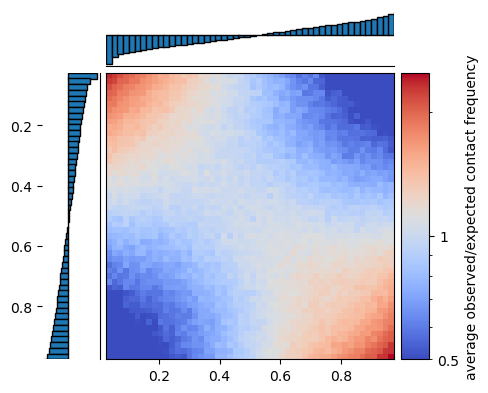

In [148]:
saddleplot(eigenvector_track,
           interaction_sum_hu/interaction_count_hu,
           N_GROUPS,
           qrange=(Q_LO,Q_HI),
           cbar_kws={'label':'average observed/expected contact frequency'}
          );

In [149]:
hu_values = interaction_sum_hu/interaction_count_hu
hu_values = np.nan_to_num(hu_values, nan=0)
nt_values

array([[3.70197882, 2.80994142, 2.63429611, ..., 0.34819875, 0.34659245,
        0.27139746],
       [2.80994142, 2.43228596, 2.27618559, ..., 0.36099002, 0.33987536,
        0.27336068],
       [2.63429611, 2.27618559, 2.10229628, ..., 0.35022375, 0.35481583,
        0.31921132],
       ...,
       [0.34819875, 0.36099002, 0.35022375, ..., 2.15022723, 2.33213242,
        2.85434799],
       [0.34659245, 0.33987536, 0.35481583, ..., 2.33213242, 2.60154295,
        3.05662287],
       [0.27139746, 0.27336068, 0.31921132, ..., 2.85434799, 3.05662287,
        3.7914966 ]])

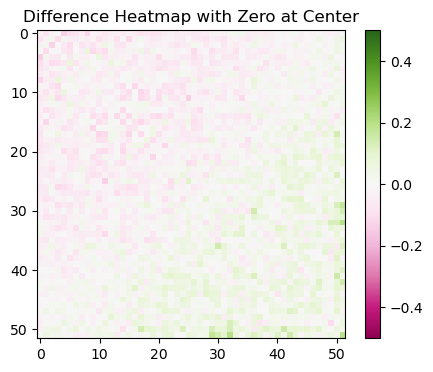

In [150]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.linalg import logm, expm


# Assuming difference is the difference between hu_values and nt_values
# difference = logm(hu_values / nt_values)/np.log(2.0)
difference = nt_values - hu_values
# difference = np.nan_to_num(difference, nan=0)
# difference.sort(axis=-1)
# difference.sort(axis=-1)

difference = np.flipud(np.fliplr(difference))
# difference = np.fliplr(difference)

# Determine the normalization to ensure zero is centered
vmin = -0.5
vmax = 0.5

midpoint = 0.0

# Create the figure
fig = plt.figure(figsize=(5, 4))

# Use TwoSlopeNorm to center the colormap at zero
norm = TwoSlopeNorm(vmin=vmin, vcenter=midpoint, vmax=vmax)

# Plot the heatmap with zero at the center using the custom normalization
plt.imshow(difference, cmap='PiYG', vmin=vmin, vmax=vmax)
plt.colorbar(orientation='vertical')
plt.title('Difference Heatmap with Zero at Center')
plt.savefig('2023-HiC-HU_minus_NT-MRC5-merged-rerun_merged_sort_MAPQ_30_wt_50000.cool.svg', dpi=1200, format='svg')
plt.show()

In [124]:
matrix1 = interaction_sum_hu  # Matrix to take the upper triangle from
matrix2 = interaction_sum  # Matrix to take the lower triangle from

# Ensure both matrices have the same shape
assert matrix1.shape == matrix2.shape, "Both matrices must have the same shape."

# Create a third matrix by combining the upper and lower triangles
combined_matrix = np.zeros_like(matrix1)  # Initialize the combined matrix with zeros

# Fill the upper triangle from matrix1
combined_matrix[np.triu_indices_from(combined_matrix)] = matrix1[np.triu_indices_from(matrix1)]

# Fill the lower triangle from matrix2
combined_matrix[np.tril_indices_from(combined_matrix)] = matrix2[np.tril_indices_from(matrix2)]

# The diagonal can be taken from either matrix1 or matrix2 depending on your choice
# If you want to keep the diagonal from one specific matrix, set that here:
combined_matrix[np.diag_indices_from(combined_matrix)] = matrix1[np.diag_indices_from(matrix1)]  # or matrix2

matrix1 = interaction_count_hu  # Matrix to take the upper triangle from
matrix2 = interaction_count  # Matrix to take the lower triangle from

# Ensure both matrices have the same shape
assert matrix1.shape == matrix2.shape, "Both matrices must have the same shape."

# Create a third matrix by combining the upper and lower triangles
combined_matrix_count = np.zeros_like(matrix1)  # Initialize the combined matrix with zeros

# Fill the upper triangle from matrix1
combined_matrix_count[np.triu_indices_from(combined_matrix_count)] = matrix1[np.triu_indices_from(matrix1)]

# Fill the lower triangle from matrix2
combined_matrix_count[np.tril_indices_from(combined_matrix_count)] = matrix2[np.tril_indices_from(matrix2)]

# The diagonal can be taken from either matrix1 or matrix2 depending on your choice
# If you want to keep the diagonal from one specific matrix, set that here:
combined_matrix_count[np.diag_indices_from(combined_matrix_count)] = matrix1[np.diag_indices_from(matrix1)]  # or matrix2

In [ ]:
saddleplot(eigenvector_track_hu,
           combined_matrix/combined_matrix_count,
           N_GROUPS,
           qrange=(Q_LO,Q_HI),
           cbar_kws={'label':'average observed/expected contact frequency'}
          );

In [ ]:
matrix_hu = clr.matrix(sparse=True, balance=True)
matrix_hu

In [ ]:
saddleplot(eigenvector_track_hu,
           (interaction_sum_hu/interaction_count_hu)/(interaction_sum/interaction_count),
           N_GROUPS,
           qrange=(Q_LO,Q_HI),
           cbar_kws={'label':'average observed/expected contact frequency'}
          );

In [ ]:
interaction_sum/interaction_count